In [1]:
import os
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import pickle
from typing import Any

from pollen_worker.pollen_utils import get_clients_population_dict

# Change font to respect submission requirements
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = "Times New Roman"
plt.rcParams["font.size"] = 14
plt.rcParams["font.weight"] = "normal"
HOME_DIR = Path(f"{os.getenv('HOME', '')}")

In [2]:
def read_all_pickle(path: Path) -> list[list[Any]]:
    out = []
    with open(path, "rb") as f:
        try:
            while True:
                out.append(pickle.load(f))
        except EOFError:
            pass
    return out


def get_cct_dataframe_pickle(path_to_pickle: Path) -> pd.DataFrame:
    """Reads a csv file and returns a dataframe with the CCT data."""
    functions = {
        0: "init",
        1: "fit",
        2: "end fit-begin aggregate",
        3: "end aggregate",
        4: "end fit",
    }
    worker_out = read_all_pickle(path_to_pickle)
    df = pd.DataFrame(
        np.concatenate(worker_out),
        columns=["fn", "timestamp", "round", "cid"],
        dtype=np.float64,
    )
    df.fn = df.fn.apply(lambda x: functions[x])
    df["timedelta"] = df.timestamp.map(lambda a: a - df.timestamp[0])
    df = df.groupby(["cid", "round"]).timestamp.agg(["min", "max"]).reset_index()
    df["delta"] = df["max"] - df["min"]
    return df

DEBUG flwr 2024-01-20 17:14:32,214 | pollen_utils.py:294 | Length of cids list before filtering 11325
DEBUG flwr 2024-01-20 17:14:32,215 | pollen_utils.py:296 | Length of cids list after filtering 11325
DEBUG flwr 2024-01-20 17:14:32,217 | pollen_utils.py:298 | Randomly sampled clients with state 1337


$KL(node~0~|~node~1)~=~8.6$
$KL(node~1~|~node~0)~=~4.4$


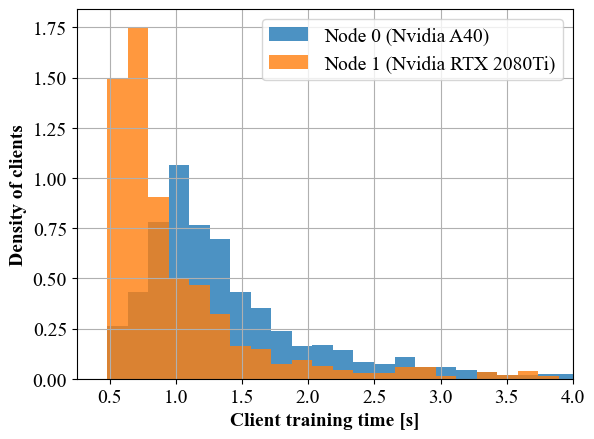

In [4]:
results_root = Path(f"{HOME_DIR}/projects/fertilizer/logs/flwrplus_hetero")


def kl(p, q):
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)

    return np.sum(np.where(p != 0, p * np.log((p / (q + 1e-10)) + 1e-10), 0))


dataset, cid_samples_dict = "openimage1", get_clients_population_dict(
    name="openimage", batch_size=1, seed=1337
)

dfs = []
folder = results_root / dataset / "a40" / "round_robin"
for file in folder.glob("stats_worker*"):
    df = get_cct_dataframe_pickle(file)
    df["gpu"] = "Node 0 (Nvidia A40)"
    dfs.append(df)
folder = results_root / dataset / "2080" / "round_robin"
for file in folder.glob("stats_worker*"):
    df = get_cct_dataframe_pickle(file)
    df["gpu"] = "Node 1 (Nvidia RTX 2080Ti)"
    dfs.append(df)
df = pd.concat(dfs)

df = df[df.cid != -1]
cid_samples_df = pd.DataFrame(cid_samples_dict.items(), columns=["cid", "n_samples"])
cid_samples_df["n_batches"] = cid_samples_df.n_samples // 20

lines = []
line = None
for gpu in df.gpu.unique():
    dff = df[df.gpu == gpu].merge(cid_samples_df, how="inner", on="cid")
    dff.reset_index(drop=True)
    line = plt.hist(
        dff.delta,
        density=True,
        bins=line[1] if line is not None else "auto",
        label=f"{gpu}",
        alpha=0.8,
    )
    lines.append(line)

print(
    f"$KL(node~0~|~node~1)~=~{kl(p=lines[0][0], q=lines[1][0]):.1f}$\n$KL(node~1~|~node~0)~=~{kl(p=lines[1][0], q=lines[0][0]):.1f}$"
)

x_label = plt.xlabel("Client training time [s]")
x_label.set_weight("bold")
y_label = plt.ylabel("Density of clients")
y_label.set_weight("bold")
plt.xlim(0.25, 4)
plt.legend()
plt.grid()
plt.savefig(
    "hard_hetero_training_time_histo.pdf", format="pdf", dpi=800, bbox_inches="tight"
)
plt.show()